In [32]:
import pandas as pd 
import torch
import torch.optim as optim
import torch.nn as nn 
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from tqdm.notebook import tqdm
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt 
import numpy as np 

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [44]:
train_data = pd.read_csv("/kaggle/input/datasets/olegkaran/flight-price-prediction-from-aviasales/train_data_to_colab.csv")
test_data = pd.read_csv("/kaggle/input/datasets/olegkaran/flight-price-prediction-from-aviasales/test_data_to_colab.csv")

X_train = train_data.drop(columns=["value"])
y_train = train_data["value"] / 1000
X_test = test_data.drop(columns=["value"])
y_test = test_data["value"] / 1000

X_train_tensor = torch.tensor(X_train.to_numpy(), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.to_numpy(), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 128
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
loaders = {
    "train": train_dataloader, 
    "test": test_dataloader
}

In [52]:
class ResBlock(nn.Module):
    def __init__(self, dim, dropout):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return x + self.block(x)

class BaseMLP(nn.Module):
    def __init__(self, in_features, blocks, hidden_dim=512, dropout=0.3):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.blocks = nn.Sequential(*[ResBlock(dim=hidden_dim, dropout=dropout) for _ in range(blocks)])
        self.output_layer = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.blocks(x)
        x = self.output_layer(x)
        return x

In [53]:
from torchinfo import summary
model = BaseMLP(in_features = 66, blocks=7).to(device)
summary(model, input_size=(1, 66), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
BaseMLP                                  [1, 1]                    --
├─Sequential: 1-1                        [1, 512]                  --
│    └─Linear: 2-1                       [1, 512]                  34,304
│    └─LayerNorm: 2-2                    [1, 512]                  1,024
│    └─ReLU: 2-3                         [1, 512]                  --
│    └─Dropout: 2-4                      [1, 512]                  --
├─Sequential: 1-2                        [1, 512]                  --
│    └─ResBlock: 2-5                     [1, 512]                  --
│    │    └─Sequential: 3-1              [1, 512]                  527,360
│    └─ResBlock: 2-6                     [1, 512]                  --
│    │    └─Sequential: 3-2              [1, 512]                  527,360
│    └─ResBlock: 2-7                     [1, 512]                  --
│    │    └─Sequential: 3-3              [1, 512]                  5

In [54]:
def train_one_epoch(model, optimizer, loss_fn, train_dataloader, device):
    running_loss = 0.0
    all_preds = []
    all_labels = []
    model.train()
    for x_batch, y_batch in tqdm(train_dataloader):
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(x_batch)
        loss = loss_fn(preds.squeeze(), y_batch)
        running_loss += loss.item()
        all_preds.append(preds)
        all_labels.append(y_batch)
        loss.backward()
        optimizer.step()
    epoch_loss = running_loss / len(train_dataloader)
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    real_preds = all_preds.squeeze() * 1000
    real_labels = all_labels * 1000
    epoch_mae = mean_absolute_error(real_preds.detach().cpu(), real_labels.cpu())
    return (epoch_loss, epoch_mae)


def val_one_epoch(model, loss_fn, val_dataloader, device):
    running_loss = 0.0
    all_preds = []
    all_labels = []
    model.eval()
    with torch.no_grad():
        for x_batch, y_batch in tqdm(val_dataloader):
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            preds = model(x_batch)
            loss = loss_fn(preds.squeeze(), y_batch)
            running_loss += loss.item()
            all_preds.append(preds)
            all_labels.append(y_batch)
        epoch_loss = running_loss / len(val_dataloader)
        all_preds = torch.cat(all_preds)
        all_labels = torch.cat(all_labels)
        real_preds = all_preds.squeeze() * 1000
        real_labels = all_labels * 1000
        epoch_mae = mean_absolute_error(real_preds.detach().cpu(), real_labels.cpu())
    return (epoch_loss, epoch_mae)


def train(model, optimizer, loss_fn, train_dataloader, val_dataloader, device, epochs):
    history = {
        "train_loss": [], "train_mae": [],
        "val_loss": [], "val_mae": []
    }
    best_mae = float("inf")
    best_epoch = 0.0
    for epoch in range(epochs):
        print(f"Epoch: {epoch + 1}")
        train_loss, train_mae = train_one_epoch(model, optimizer, loss_fn, train_dataloader, device)
        val_loss, val_mae = val_one_epoch(model, loss_fn, val_dataloader, device)
        history["train_loss"].append(train_loss)
        history["train_mae"].append(train_mae)
        history["val_loss"].append(val_loss)
        history["val_mae"].append(val_mae)

        print(f"Train Loss: {train_loss}, Train MAE: {train_mae}")
        print(f"Val Loss: {val_loss}, Val MAE: {val_mae}")

        if train_mae < best_mae and epoch > 1:
            best_mae = train_mae
            best_epoch = epoch + 1
            torch.save(model.state_dict(), "best_model.pth")
    print(f"Лучший MAE на train: {best_mae} на эпохе {best_epoch}")
    return (history, model)

def visualize_training(train_losses, val_losses) -> None:
    plt.title("График лосса на train и val")
    plt.plot(train_losses, label="Train_loss", color="orange")
    plt.plot(val_losses, label="Val_loss", color="red")
    plt.legend()
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

Epoch: 1


  0%|          | 0/185 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

Train Loss: 186.18387649123733, Train MAE: 9715.523057805503
Val Loss: 127.66468372750789, Val MAE: 8871.940260420797
Epoch: 2


  0%|          | 0/185 [00:00<?, ?it/s]

...

  0%|          | 0/47 [00:00<?, ?it/s]

Train Loss: 31.948150593525654, Train MAE: 3489.2184783159373
Val Loss: 27.980225197812345, Val MAE: 3236.5250112026742
Epoch: 100


  0%|          | 0/185 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

Train Loss: 32.18338388494543, Train MAE: 3483.895514069636
Val Loss: 28.31736448977856, Val MAE: 3278.4718034644216
Лучший MAE на train: 3473.298148507959 на эпохе 98


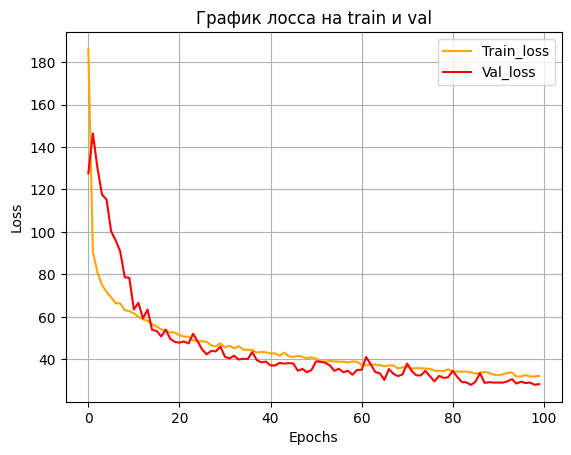

In [55]:
epochs = 100
model = BaseMLP(in_features=66, blocks=7)
model.to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-5)
loss_fn = nn.MSELoss()
history, model = train(
    model, 
    optimizer, 
    loss_fn, 
    loaders["train"], 
    loaders["test"], 
    device, 
    epochs
)
visualize_training(history["train_loss"], history["val_loss"])